## Portfolio 4

## Dataset description

For the present analysis we explore the data set CDC Diabetes Health Indicators

The dataset is available at https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

Diabetes is a very common disease which is present through out the world. Diabetes is usually detected in humans only when the disease has progressed. However, prioir to the onset of diabetes their are various other secondary symptoms which can be used as a precursor to diabetes. Analysing the precursors through ML models can provide essential information on the prevalance of diabetes and thus its management. The binary dataset has been used for the analysis

In this portfolio we explore:
* Can the various symptoms be used to predict the presence of diabetes through ML models?
* What are the best features suitable for the prediction of diabetes?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection
from sklearn import tree
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report)

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")
# Glimpse of the dataset
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

The dataset does not have any missing data. In addition, all the variables are numerical data.

In [4]:
# create a copy of the dataset for all manipulations
import copy
df2 = copy.deepcopy(df)

In [5]:
df2.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


<Axes: title={'center': 'Distribution of presence of diabetes'}, ylabel='count'>

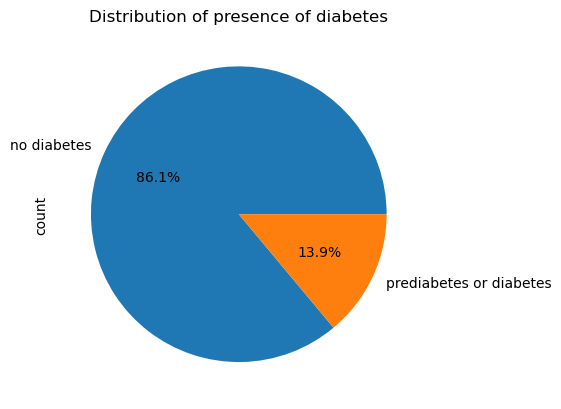

In [6]:
# Mapping the variables Diabetes_binary        
df2['Diabetes_binary'] = df2['Diabetes_binary'].map({0.0:"no diabetes", 1.0:"prediabetes or diabetes"})
# pie chart for distribution of Diabetes
dfdiabetes = pd.crosstab(index=df2["Diabetes_binary"],  columns="count")
plot1 = dfdiabetes.plot.pie(y = 'count', title="Distribution of presence of diabetes", autopct='%1.1f%%', legend = False)
plot1

<Axes: title={'center': 'Distribution of presence of BP'}, ylabel='count'>

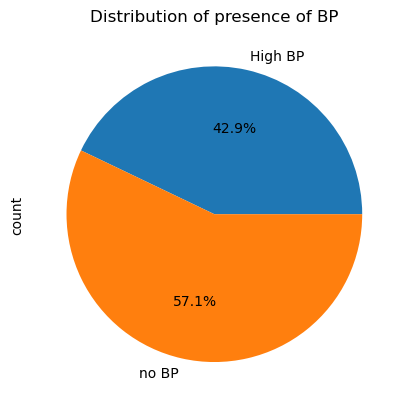

In [7]:
# Mapping the variables Presence of BP 
df2['HighBP'] = df2['HighBP'].map({0.0:"no BP", 1.0:"High BP"})
# pie chart for distribution of BP
dfBP = pd.crosstab(index=df2["HighBP"],  columns="count")
plot1 = dfBP.plot.pie(y = 'count', title="Distribution of presence of BP", autopct='%1.1f%%', legend = False)
plot1

<Axes: title={'center': 'Distribution of presence of Cholesterol'}, ylabel='count'>

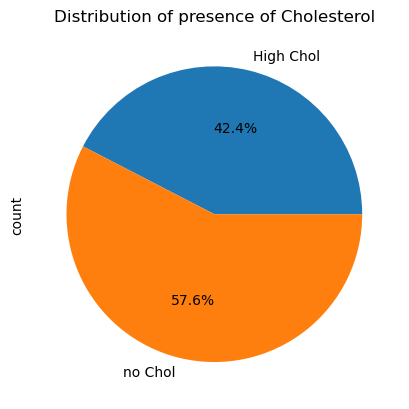

In [8]:
# Mapping the variables Presence of Chol
df2['HighChol'] = df2['HighChol'].map({0.0:"no Chol", 1.0:"High Chol"})
# pie chart for distribution of Chol
dfchol = pd.crosstab(index=df2["HighChol"],  columns="count")
plot1 = dfchol.plot.pie(y = 'count', title="Distribution of presence of Cholesterol", autopct='%1.1f%%', legend = False)
plot1

<Axes: title={'center': 'Distribution of presence of Cholesterol in last 5 years'}, ylabel='count'>

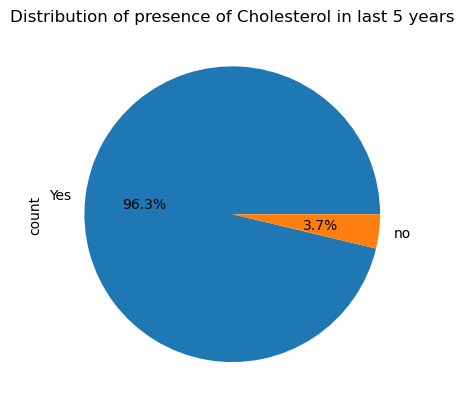

In [9]:
# Mapping the variables Presence of Chol in last 5 years
df2['CholCheck'] = df2['CholCheck'].map({0.0:"no", 1.0:"Yes"})
# pie chart for distribution of Chol in last 5 years
dfcholC = pd.crosstab(index=df2["CholCheck"],  columns="count")
plot1 = dfcholC.plot.pie(y = 'count', title="Distribution of presence of Cholesterol in last 5 years", autopct='%1.1f%%', legend = False)
plot1

In [10]:

df2.groupby('Diabetes_binary')['BMI'].describe()

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,,,,,,,,
no diabetes,218334.0,27.805770,6.291414,12.0,24.0,27.0,31.0,98.0
prediabetes or diabetes,35346.0,31.944011,7.363401,13.0,27.0,31.0,35.0,98.0


<Axes: xlabel='Diabetes_binary', ylabel='BMI'>

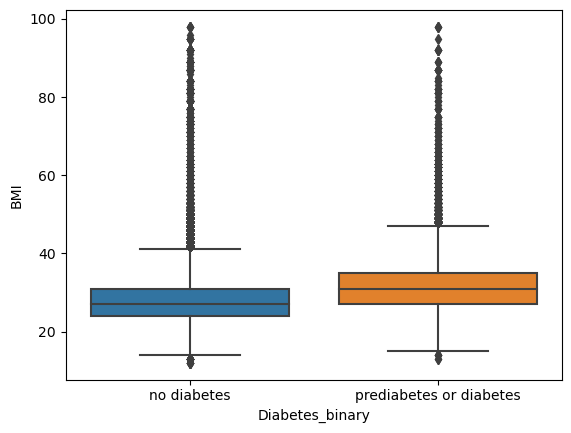

In [11]:
# Distribution of BMI by diabetes
sns.boxplot(x = df2['Diabetes_binary'], 
            y = df2['BMI'])

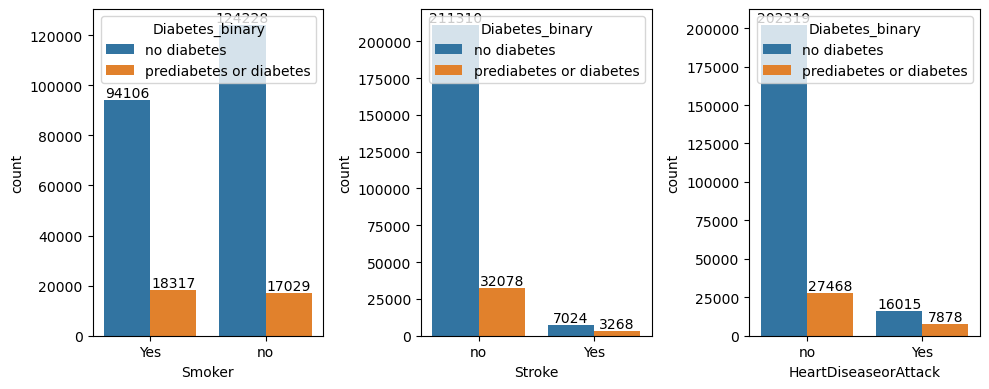

In [12]:
# Mapping the variables 
df2['Smoker'] = df2['Smoker'].map({0.0:"no", 1.0:"Yes"})
df2['Stroke'] = df2['Stroke'].map({0.0:"no", 1.0:"Yes"})
df2['HeartDiseaseorAttack'] = df2['HeartDiseaseorAttack'].map({0.0:"no", 1.0:"Yes"})
cols=['Smoker','Stroke','HeartDiseaseorAttack']
f, axs = plt.subplots(1, len(cols), figsize=(10, 4))
for ax, col in zip(axs, cols):
    sns.countplot(data=df2, x=col, hue="Diabetes_binary", ax=ax)
    for label in ax.containers:
        ax.bar_label(label)
f.tight_layout()

The percentage of people who have diabetes is low (13.9%) as compared to those who do not have (86.1%)
To correct the imbalance SMOTE function is used 

In [13]:

from imblearn.over_sampling import SMOTE

# Separate features and target variable
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']
smote=SMOTE()
smote.fit(X,y)
X,y=smote.fit_resample(X,y)

In [14]:
# Splitting the datafile into train and test in the ratio of 70:30
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import classification_report

modelLR = LogisticRegression(solver='lbfgs', max_iter=1000 )
result = modelLR.fit(X_train, y_train)
predict = modelLR.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predict) 
# Print the prediction accuracy
print("Accuracy of Logistic Regression model:",accuracy) 

Accuracy of Logistic Regression model: 0.7570018549476721


In [16]:
cm = confusion_matrix(y_test, modelLR.predict(X_test))
cm

array([[47794, 17800],
       [14033, 51374]])

[ 0.88492441  0.6800857   1.60121426  0.07102191  0.00332638 -0.0238497
  0.11504468  0.02727405 -0.03395826  0.05958507 -1.04790674  0.24551375
 -0.1087246   0.66114896 -0.00323144 -0.01005374  0.03230474  0.29437473
  0.14581085 -0.02210364 -0.06052593]


<Axes: title={'center': 'Important Features based on Logistic Regression'}, ylabel='Feature'>

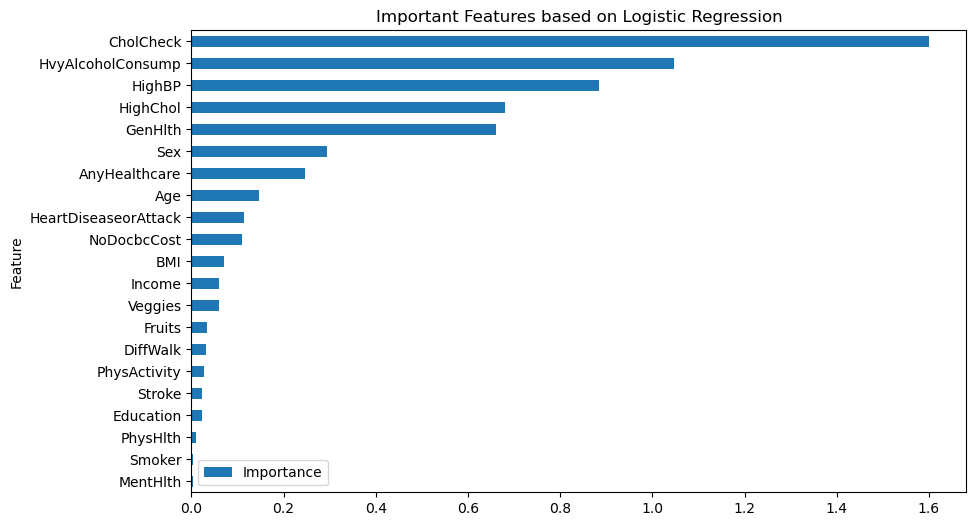

In [17]:
import numpy as np
coefficients = modelLR.coef_[0]
print(coefficients)
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', title = 'Important Features based on Logistic Regression',kind='barh', figsize=(10, 6))

In [18]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

         0.0       0.77      0.73      0.75     65594
         1.0       0.74      0.79      0.76     65407

    accuracy                           0.76    131001
   macro avg       0.76      0.76      0.76    131001
weighted avg       0.76      0.76      0.76    131001



Random Forest accuracy: 0.834444011877772


<Axes: >

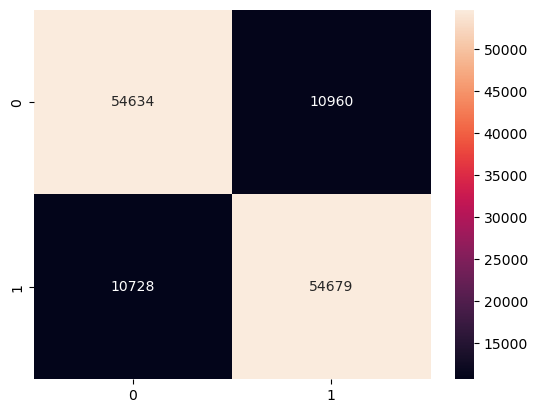

In [19]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns 
model_rf = RandomForestClassifier(n_estimators=1000 , oob_score = True, n_jobs = -1,
                                  random_state =50, max_features = "sqrt",
                                  max_leaf_nodes = 30)
model_rf.fit(X_train, y_train)
# Make predictions
predict = model_rf.predict(X_test)
probs = model_rf.predict_proba(X_test)
# Print the prediction accuracy
accuracy = metrics.accuracy_score(y_test, predict)
print("Random Forest accuracy:",accuracy) 

cm = confusion_matrix(y_test, model_rf.predict(X_test))
sns.heatmap(cm,annot=True,fmt="d")

In [20]:
cm

array([[54634, 10960],
       [10728, 54679]])

[0.29943234 0.16945886 0.00124756 0.05537562 0.01293625 0.00115509
 0.04033632 0.02984766 0.00506305 0.00265124 0.00942247 0.00089772
 0.00277206 0.19830182 0.00069344 0.00406613 0.07594978 0.01480838
 0.04850173 0.01310712 0.01397537]


<Axes: title={'center': 'Important features based on Random Forest model'}, ylabel='Feature'>

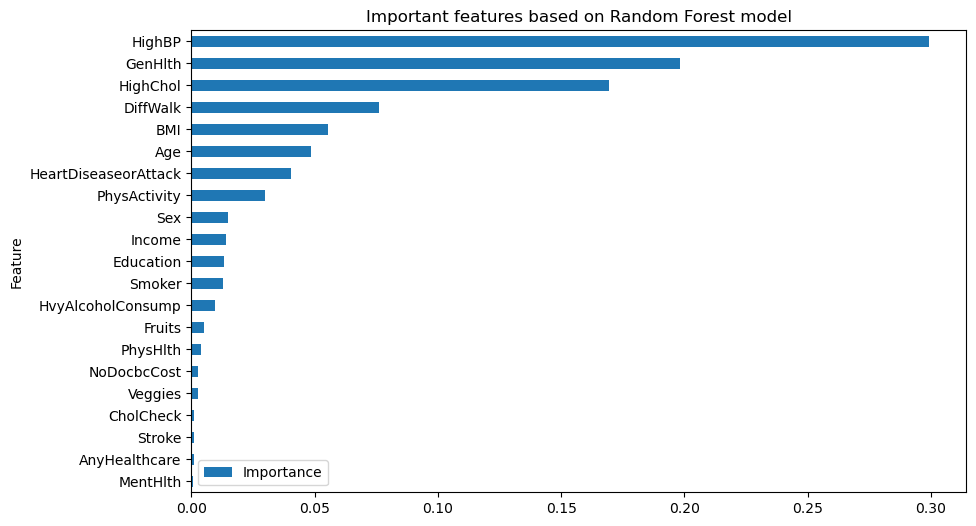

In [21]:
coefficients = model_rf.feature_importances_
print(coefficients)
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance',title = 'Important features based on Random Forest model', kind='barh', figsize=(10, 6))

In [22]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

         0.0       0.84      0.83      0.83     65594
         1.0       0.83      0.84      0.83     65407

    accuracy                           0.83    131001
   macro avg       0.83      0.83      0.83    131001
weighted avg       0.83      0.83      0.83    131001



In [23]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()
clf = clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.8767337653911039


<Axes: >

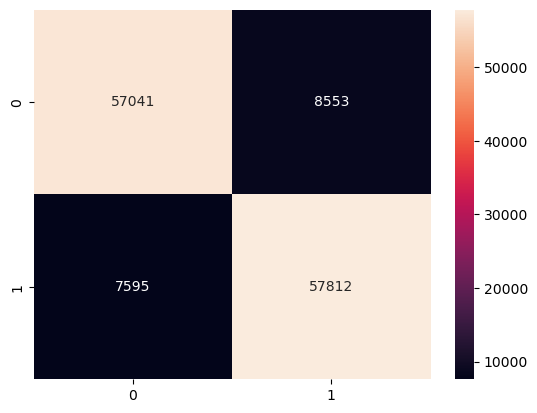

In [24]:
cm = confusion_matrix(y_test, clf.predict(X_test))
sns.heatmap(cm,annot=True,fmt="d")

In [25]:
cm

array([[57041,  8553],
       [ 7595, 57812]])

In [26]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

         0.0       0.84      0.83      0.83     65594
         1.0       0.83      0.84      0.83     65407

    accuracy                           0.83    131001
   macro avg       0.83      0.83      0.83    131001
weighted avg       0.83      0.83      0.83    131001



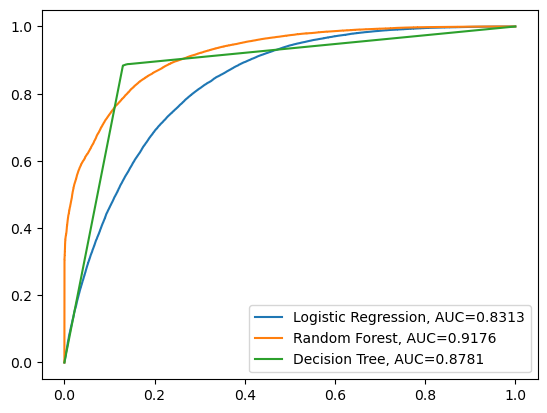

In [27]:
#set up plotting area
plt.figure(0).clf()
y_pred = modelLR.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred)
auc = round(metrics.roc_auc_score(y_test, y_pred), 4)
plt.plot(fpr,tpr,label="Logistic Regression, AUC="+str(auc))

y_pred = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred)
auc = round(metrics.roc_auc_score(y_test, y_pred), 4)
plt.plot(fpr,tpr,label="Random Forest, AUC="+str(auc))

y_pred = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred)
auc = round(metrics.roc_auc_score(y_test, y_pred), 4)
plt.plot(fpr,tpr,label="Decision Tree, AUC="+str(auc))

#add legend
plt.legend()

# Summary
The prevalance of Diabetes is a worldwide problem. Prediction of conditions suitable for onset of diabetes would help in the management of the disease. There are multiple symptoms which can help predict the presence of diabetes. Machine learning models can be ideal methods through which the onset of diabetes can be predicted without the need for costly tests. 

In this project we attempted to predict the presence of diabetes based on multiple variables. Since the target variable (diabetes) was binary hence classification models were used to predict the presence of diabetes. 

Three different models - logistic regression, decision tree and random forest were used in this project. It was observed that the random forest model works best for the prediction of diabetes based on the given variables.  